### [Dependencies]

In [39]:
import os
import umap
import warnings
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from tqdm.notebook import tqdm
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

bee = 'Jataí' #'Ambas' #'Mandaçaia' #'Jataí'

os.makedirs('../graficos/',          exist_ok=True)
os.makedirs(f'../graficos/{bee}', exist_ok=True)

load_path = '../..'
save_path = f'../graficos/{bee}'


warnings.filterwarnings('ignore', message='.*n_jobs value 1 overridden.*')

### [Read data]

In [40]:
if bee == 'Ambas':
    df = []
    for aux_bee in ['Jataí', 'Mandaçaia']:
            
        aux_df = pd.read_excel(f'{load_path}/{aux_bee}_infravermelho_duas_coletas.xlsx')
        aux_df = aux_df.T.reset_index()
        
        columns = aux_df.iloc[0].tolist()
        columns[0:3] = ['Abelha', 'Dia_coleta', 'IDX_produtor'] if aux_bee == 'Mandaçaia' else ['Dia_coleta', 'Abelha', 'IDX_produtor']
        
        aux_df.columns = columns
        aux_df = aux_df[1:]
        
        aux_df['Rodada_coleta'] = aux_df['Dia_coleta'].str.extract(r'(\d+)º').astype(int).values
        aux_df['IDX_produtor']  = aux_df['IDX_produtor'].str.replace('Produtor ', '', regex=False).astype(int)
        aux_df['Dia_coleta']    = aux_df.groupby('Rodada_coleta').cumcount() + 1

        df.append(aux_df)

    df = pd.concat(df).dropna(axis=1)
    df['Abelha'] = ['Jataí' for _ in range(16)] + ['Mandaçaia' for _ in range(16)]
    
else: 
    df = pd.read_excel(f'{load_path}/{bee}_infravermelho_duas_coletas.xlsx')
    df = df.T.reset_index()
    
    columns = df.iloc[0].tolist()
    columns[0:3] = ['Abelha', 'Dia_coleta', 'IDX_produtor'] if bee == 'Mandaçaia' else ['Dia_coleta', 'Abelha', 'IDX_produtor']
    
    df.columns = columns
    df = df[1:]
    
    df['Rodada_coleta'] = df['Dia_coleta'].str.extract(r'(\d+)º').astype(int).values
    df['IDX_produtor'] = df['IDX_produtor'].str.replace('Produtor ', '', regex=False).astype(int)
    df['Dia_coleta'] = df.groupby('Rodada_coleta').cumcount() + 1

    if bee == 'Mandaçaia':
        df['Abelha'] = ['Mandaçaia' for _ in range(16)]
    
    df.head()

In [41]:
df

,Dia_coleta,Abelha,IDX_produtor,4000,3999,3998,3997,3996,3995,3994,...,658,657,656,655,654,653,652,651,650,Rodada_coleta
1,1,JATAÍ,1,100,99.995513,99.992737,99.9917,99.99185,99.992837,99.994127,...,99.322983,98.514537,98.14798,98.87685,98.15767,96.38628,97.676523,98.939357,100.83396,1
2,2,JATAÍ,2,100,99.99462,99.994017,99.988213,99.982753,99.98002,99.981893,...,99.101097,98.686977,99.0192,99.381357,98.198847,97.36968,97.516307,99.32453,100.516735,1
3,3,JATAÍ,3,100,100.001873,100.003493,100.003477,100.00228,100.00145,100.0017,...,98.023333,97.086957,96.893953,97.247947,97.3147,97.140197,97.92563,99.290683,101.011927,1
4,4,JATAÍ,4,100,100.001053,100.000393,99.999377,99.994727,99.994683,99.997733,...,100.155547,99.407333,99.56157,98.271427,96.879717,96.023513,97.0668,98.72557,100.74969,1
5,5,JATAÍ,5,100,100.002107,100.002913,100.003307,99.99521,99.997057,100.00043,...,100.36313,99.592973,99.704393,100.024977,96.684607,95.810703,96.893257,98.506587,100.467617,1
6,6,JATAÍ,6,100,99.995467,99.992313,99.990977,99.989517,99.98673,99.98344,...,99.59384,99.817563,99.892533,99.975283,100.153513,100.266587,100.24297,100.063923,100.063923,1
7,7,JATAÍ,7,100,99.990267,99.98342,99.981567,99.983187,99.97544,99.976467,...,100.05541,100.09028,100.106803,100.111793,100.263643,100.236147,99.620817,99.74431,99.74431,1
8,8,JATAÍ,8,99.99333,99.9892,99.977453,99.9738,99.964723,99.964807,99.966357,...,99.510363,99.52746,99.454187,99.421597,99.504017,99.615243,99.698,99.799663,99.799663,1
9,1,JATAÍ,1,100,100,100,100.01,100.01,100.01,100,...,99.32,99.42,99.34,99.26,99.24,99.19,99.08,99.05,99.12,2
10,2,JATAÍ,2,100,100,99.99,99.99,99.99,99.99,99.99,...,98.39,98.57,98.56,98.47,98.4,98.29,98.16,98.12,98.14,2


### [Signal Visualization]

In [42]:
metadata_cols = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
freq_cols     = [col for col in df.columns if col not in metadata_cols]

df_plot = df.melt(
    id_vars=metadata_cols, 
    value_vars=freq_cols, 
    var_name='Frequencia_cm1', 
    value_name='Intensidade'
)

df_plot['Frequencia_cm1'] = df_plot['Frequencia_cm1'].astype(float)

df_plot['Legenda'] = 'Produtor ' + df_plot['IDX_produtor'].astype(str)

df_plot['Rodada_coleta'] = df_plot['Rodada_coleta'].map({1: '1º Dia', 2: '2º Dia'})

fig = px.line(
    df_plot,
    x='Frequencia_cm1',
    y='Intensidade',
    color='Legenda',        
    line_dash='Rodada_coleta', 
    hover_name='Abelha',
    title=f'Frequency Spectrum of Honey {bee} Samples (FTIR)',
    labels={
        'Frequencia_cm1': 'Wavenumber (cm⁻¹)',
        'Intensidade': 'Transmitance',
        'Rodada_coleta': 'Sampling' 
    },
    template='plotly_white'
)

fig.update_layout(
    xaxis=dict(autorange='reversed'),
    legend_title_text='Amostras',
    hovermode="x unified" 
)

fig.update_traces(line=dict(width=1.5))

fig.update_layout(
    width=1000,  
    height=700, 
)
fig.write_html(f"{save_path}/Frequencias.html")

### [PCA Visualization]

#### [2D]

In [43]:
freqs = [
    (3800, 3015), (3015, 2450), (1770, 1530), 
    (1520, 1200), (1200, 905), (905, 700), 
    ('Todas', 'Todas')
]

for freq_max, freq_min in tqdm(freqs, total=len(freqs)):
    cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
    all_freqs      = [col for col in df.columns if col not in cols_metadados]

    if freq_max == 'Todas':
        freq_selected = all_freqs
        file_name = "Todas"
    else:
        freq_selected = [
            col for col in all_freqs 
            if freq_min <= float(col) <= freq_max
        ]
        file_name = f"{freq_max}_{freq_min}"

    filtered = df[freq_selected].values

    redutor = PCA(n_components=2, random_state=42)
    
    df_2D = pd.DataFrame(
        data=redutor.fit_transform(filtered), 
        columns=['Component 1', 'Component 2']
    )
   
    df_2D['IDX_produtor']  = ('Beekeeper ' + df['IDX_produtor'].astype(str)).values
    df_2D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Sampling').values
    df_2D['Abelha']        = df['Abelha'].values

    fig_prod = px.scatter(
        df_2D, x='Component 1', y='Component 2',
        color='IDX_produtor', text='Rodada_coleta', hover_name='Abelha',
        hover_data={'Component 1': False, 'Component 2': False}
    )

    fig_rodada = px.scatter(
        df_2D, x='Component 1', y='Component 2',
        color='Rodada_coleta', text='IDX_produtor', hover_name='Abelha',
        hover_data={'Component 1': False, 'Component 2': False}
    )

    if bee == 'Ambas':
        fig_abelha = px.scatter(
            df_2D, x='Component 1', y='Component 2',
            color='Abelha', text='Rodada_coleta', hover_name='IDX_produtor',
            hover_data={'Component 1': False, 'Component 2': False}
        )
    

    fig = go.Figure()

    for trace in fig_prod.data:
        fig.add_trace(trace)

    for trace in fig_rodada.data:
        trace.visible = False
        fig.add_trace(trace)

    if bee == 'Ambas':
        for trace in fig_abelha.data:
            trace.visible = False
            fig.add_trace(trace)

    num_prod_traces   = len(fig_prod.data)
    num_rodada_traces = len(fig_rodada.data)
    num_abelha_traces = len(fig_abelha.data) if bee == 'Ambas' else 0
    

    show_produtor = [True]  * num_prod_traces + [False] * num_rodada_traces + [False] * num_abelha_traces
    show_rodada   = [False] * num_prod_traces + [True]  * num_rodada_traces + [False] * num_abelha_traces

    if bee == 'Ambas': 
        show_abelha = [False] * num_prod_traces + [False] * num_rodada_traces + [True] * num_abelha_traces


    my_buttons = [
        dict(
            label="Agrupar por Produtor",
            method="update",
            args=[{"visible": show_produtor}]
        ),
        dict(
            label="Agrupar por Coleta",
            method="update",
            args=[{"visible": show_rodada}]
        )
    ]


    if bee == 'Ambas':
        my_buttons.append(
            dict(
                label="Agrupar por Abelha",
                method="update",
                args=[{"visible": show_abelha}]
            )
        )


    fig.update_layout(
        title=f'PCA Analysis of {bee}: Grouping of Producers and Sampling',
        template='plotly_white',
        width=700, 
        height=700,
        xaxis_title=f'Principal Component 1 ({redutor.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'Principal Component 2 ({redutor.explained_variance_ratio_[1]*100:.1f}%)',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.5,
                y=-0.15,
                xanchor="center",
                yanchor="top",
                showactive=True,
                buttons=my_buttons 
            )
        ]
    )

    fig.update_traces(
        textposition='top center',
        textfont_size=9, 
        marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
    )

    fig.write_html(f"{save_path}/PCA_2D_{file_name}.html")

  0%|          | 0/7 [00:00<?, ?it/s]

#### [3D]

In [44]:
freqs = [
    (3800, 3015), (3015, 2450), (1770, 1530), 
    (1520, 1200), (1200, 905), (905, 700), 
    ('Todas', 'Todas')
]

for freq_max, freq_min in tqdm(freqs, total=len(freqs)):
    cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
    all_freqs      = [col for col in df.columns if col not in cols_metadados]

    if freq_max == 'Todas':
        freq_selected = all_freqs
        file_name = "Todas"
    else:
        freq_selected = [
            col for col in all_freqs 
            if freq_min <= float(col) <= freq_max
        ]
        file_name = f"{freq_max}_{freq_min}"

    filtered = df[freq_selected].values

    redutor = PCA(n_components=3, random_state=42)
    
    df_3D = pd.DataFrame(
        data=redutor.fit_transform(filtered), 
        columns=['Component 1', 'Component 2', 'Component 3']
    )
   
    df_3D['IDX_produtor']  = ('Beekeeper ' + df['IDX_produtor'].astype(str)).values
    df_3D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Sampling').values
    df_3D['Abelha']        = df['Abelha'].values

    fig_prod = px.scatter_3d(
        df_3D, 
        x='Component 1', y='Component 2', z='Component 3',
        color='IDX_produtor', text='Rodada_coleta', hover_name='Abelha',
        hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
    )

    fig_rodada = px.scatter_3d(
        df_3D, 
        x='Component 1', y='Component 2', z='Component 3',
        color='Rodada_coleta', text='IDX_produtor', hover_name='Abelha',
        hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
    )

    if bee == 'Ambas':
        fig_abelha = px.scatter_3d(
            df_3D, 
            x='Component 1', y='Component 2', z='Component 3',
            color='Abelha', text='Rodada_coleta', hover_name='IDX_produtor',
            hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
        )

    fig = go.Figure()

    for trace in fig_prod.data:
        fig.add_trace(trace)

    for trace in fig_rodada.data:
        trace.visible = False
        fig.add_trace(trace)

    if bee == 'Ambas':
        for trace in fig_abelha.data:
            trace.visible = False
            fig.add_trace(trace)

    num_prod_traces   = len(fig_prod.data)
    num_rodada_traces = len(fig_rodada.data)
    num_abelha_traces = len(fig_abelha.data) if bee == 'Ambas' else 0

    show_produtor = [True]  * num_prod_traces + [False] * num_rodada_traces + [False] * num_abelha_traces
    show_rodada   = [False] * num_prod_traces + [True]  * num_rodada_traces + [False] * num_abelha_traces

    if bee == 'Ambas': 
        show_abelha = [False] * num_prod_traces + [False] * num_rodada_traces + [True] * num_abelha_traces

    my_buttons = [
        dict(
            label="Agrupar por Produtor",
            method="update",
            args=[{"visible": show_produtor}]
        ),
        dict(
            label="Agrupar por Coleta",
            method="update",
            args=[{"visible": show_rodada}]
        )
    ]

    if bee == 'Ambas':
        my_buttons.append(
            dict(
                label="Agrupar por Abelha",
                method="update",
                args=[{"visible": show_abelha}]
            )
        )

    fig.update_layout(
        title=f'PCA Analysis of {bee}: Grouping of Producers and Sampling',
        template='plotly_white',
        width=800, 
        height=800,
        scene=dict(
            xaxis_title=f'Principal Component 1 ({redutor.explained_variance_ratio_[0]*100:.1f}%)',
            yaxis_title=f'Principal Component 2 ({redutor.explained_variance_ratio_[1]*100:.1f}%)',
            zaxis_title=f'Principal Component 3 ({redutor.explained_variance_ratio_[2]*100:.1f}%)',
            aspectmode='cube'
        ),
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.5,
                y=-0.15,
                xanchor="center",
                yanchor="top",
                showactive=True,
                buttons=my_buttons
            )
        ]
    )

    fig.update_traces(
        textposition='top center',
        textfont_size=9, 
        marker=dict(size=6, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
    )

    fig.write_html(f"{save_path}/PCA_3D_{file_name}.html")

  0%|          | 0/7 [00:00<?, ?it/s]

### [UMAP Visualization]

#### [2D]

In [45]:
freqs = [
    (3800, 3015), (3015, 2450), (1770, 1530), 
    (1520, 1200), (1200, 905), (905, 700), 
    ('Todas', 'Todas')
]

vizinhos_list = [3, 4, 5] if bee != 'Ambas' else [5, 7, 10, 15]
metricas_list = ['cosine', 'euclidean']
min_dist_list = [0.1, 0.8]

for freq_max, freq_min in tqdm(freqs, total=len(freqs)):
    cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
    all_freqs      = [col for col in df.columns if col not in cols_metadados]

    if freq_max == 'Todas':
        freq_selected = all_freqs
        file_name = "Todas"
    else:
        freq_selected = [
            col for col in all_freqs 
            if freq_min <= float(col) <= freq_max
        ]
        file_name = f"{freq_max}_{freq_min}"

    filtered = df[freq_selected].values

    for nn in vizinhos_list:
        for metrica in metricas_list:
            for md in min_dist_list:
                            
                redutor = umap.UMAP(
                                n_neighbors=nn,
                                n_components=2, 
                                metric=metrica,
                                min_dist=md,
                                random_state=42)
                
                df_2D = pd.DataFrame(
                    data=redutor.fit_transform(filtered), 
                    columns=['Component 1', 'Component 2']
                )
               
                df_2D['IDX_produtor']  = ('Beekeeper ' + df['IDX_produtor'].astype(str)).values
                df_2D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Sampling').values
                df_2D['Abelha']        = df['Abelha'].values
            
                fig_prod = px.scatter(
                    df_2D, x='Component 1', y='Component 2',
                    color='IDX_produtor', text='Rodada_coleta', hover_name='Abelha',
                    hover_data={'Component 1': False, 'Component 2': False}
                )
            
                fig_rodada = px.scatter(
                    df_2D, x='Component 1', y='Component 2',
                    color='Rodada_coleta', text='IDX_produtor', hover_name='Abelha',
                    hover_data={'Component 1': False, 'Component 2': False}
                )

                if bee == 'Ambas':
                    fig_abelha = px.scatter(
                        df_2D, x='Component 1', y='Component 2',
                        color='Abelha', text='Rodada_coleta', hover_name='IDX_produtor',
                        hover_data={'Component 1': False, 'Component 2': False}
                    )
        
                fig = go.Figure()
            
                for trace in fig_prod.data:
                    fig.add_trace(trace)
            
                for trace in fig_rodada.data:
                    trace.visible = False
                    fig.add_trace(trace)
                
                if bee == 'Ambas':
                    for trace in fig_abelha.data:
                        trace.visible = False
                        fig.add_trace(trace)
            
                num_prod_traces   = len(fig_prod.data)
                num_rodada_traces = len(fig_rodada.data)
                num_abelha_traces = len(fig_abelha.data) if bee == 'Ambas' else 0
            
                show_produtor = [True]  * num_prod_traces + [False] * num_rodada_traces
                show_rodada   = [False] * num_prod_traces + [True]  * num_rodada_traces
                
                if bee == 'Ambas': 
                    show_abelha = [False] * num_prod_traces + [False] * num_rodada_traces + [True] * num_abelha_traces

                
                my_buttons = [
                    dict(
                        label="Agrupar por Produtor",
                        method="update",
                        args=[{"visible": show_produtor}]
                    ),
                    dict(
                        label="Agrupar por Coleta",
                        method="update",
                        args=[{"visible": show_rodada}]
                    )
                ]
            
            
                if bee == 'Ambas':
                    my_buttons.append(
                        dict(
                            label="Agrupar por Abelha",
                            method="update",
                            args=[{"visible": show_abelha}]
                        )
                    )
        
                fig.update_layout(
                    title=f'UMAP Analysis of {bee}: Grouping of Producers and Sampling',
                    template='plotly_white',
                    width=700, 
                    height=700,
                    xaxis_title=f'Component 1',
                    yaxis_title=f'Component 2',
                    yaxis=dict(scaleanchor="x", scaleratio=1),
                    
                    updatemenus=[
                        dict(
                            type="buttons",
                            direction="right",
                            x=0.5,
                            y=-0.15,
                            xanchor="center",
                            yanchor="top",
                            showactive=True,
                            buttons=my_buttons 
                        )
                    ]
                )
            
                fig.update_traces(
                    textposition='top center',
                    textfont_size=9, 
                    marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
                )
            
                fig.write_html(f"{save_path}/UMAP_2D_{file_name}_{metrica}_nn{nn}_md{md}.html")

  0%|          | 0/7 [00:00<?, ?it/s]

#### [3D]

In [ ]:
freqs = [
    (3800, 3015), (3015, 2450), (1770, 1530), 
    (1520, 1200), (1200, 905), (905, 700), 
    ('Todas', 'Todas')
]

vizinhos_list = [3, 4, 5] if bee != 'Ambas' else [5, 7, 10, 15]
metricas_list = ['cosine', 'euclidean']
min_dist_list = [0.1, 0.8]

for freq_max, freq_min in tqdm(freqs, total=len(freqs)):
    cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
    all_freqs      = [col for col in df.columns if col not in cols_metadados]

    if freq_max == 'Todas':
        freq_selected = all_freqs
        file_name = "Todas"
    else:
        freq_selected = [
            col for col in all_freqs 
            if freq_min <= float(col) <= freq_max
        ]
        file_name = f"{freq_max}_{freq_min}"

    filtered = df[freq_selected].values

    for nn in vizinhos_list:
        for metrica in metricas_list:
            for md in min_dist_list:
                            
                redutor = umap.UMAP(
                                n_neighbors=nn,
                                n_components=3, 
                                metric=metrica,
                                min_dist=md,
                                random_state=42)
                
                df_3D = pd.DataFrame(
                    data=redutor.fit_transform(filtered), 
                    columns=['Component 1', 'Component 2', 'Component 3']
                )
               
                df_3D['IDX_produtor']  = ('Beekeeper ' + df['IDX_produtor'].astype(str)).values
                df_3D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Sampling').values
                df_3D['Abelha']        = df['Abelha'].values
            
                fig_prod = px.scatter_3d(
                    df_3D, x='Component 1', y='Component 2', z='Component 3',
                    color='IDX_produtor', text='Rodada_coleta', hover_name='Abelha',
                    hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
                )
            
                fig_rodada = px.scatter_3d(
                    df_3D, x='Component 1', y='Component 2', z='Component 3',
                    color='Rodada_coleta', text='IDX_produtor', hover_name='Abelha',
                    hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
                )

                if bee == 'Ambas':
                    fig_abelha = px.scatter_3d(
                        df_3D, 
                        x='Component 1', y='Component 2', z='Component 3',
                        color='Abelha', text='Rodada_coleta', hover_name='IDX_produtor',
                        hover_data={'Component 1': False, 'Component 2': False, 'Component 3': False}
                    )
                    
                fig = go.Figure()
            
                for trace in fig_prod.data:
                    fig.add_trace(trace)
            
                for trace in fig_rodada.data:
                    trace.visible = False
                    fig.add_trace(trace)

                if bee == 'Ambas':
                    for trace in fig_abelha.data:
                        trace.visible = False
                        fig.add_trace(trace)
            
                num_prod_traces   = len(fig_prod.data)
                num_rodada_traces = len(fig_rodada.data)
                num_abelha_traces = len(fig_abelha.data) if bee == 'Ambas' else 0
                
                show_produtor = [True]  * num_prod_traces + [False] * num_rodada_traces
                show_rodada   = [False] * num_prod_traces + [True]  * num_rodada_traces
                
                if bee == 'Ambas': 
                    show_abelha = [False] * num_prod_traces + [False] * num_rodada_traces + [True] * num_abelha_traces

                my_buttons = [
                    dict(
                        label="Agrupar por Produtor",
                        method="update",
                        args=[{"visible": show_produtor}]
                    ),
                    dict(
                        label="Agrupar por Coleta",
                        method="update",
                        args=[{"visible": show_rodada}]
                    )
                ]
            
                if bee == 'Ambas':
                    my_buttons.append(
                        dict(
                            label="Agrupar por Abelha",
                            method="update",
                            args=[{"visible": show_abelha}]
                        )
                    )
        
                fig.update_layout(
                    title=f'UMAP Analysis of {bee}: Grouping of Producers and Sampling',
                    template='plotly_white',
                    width=800, 
                    height=800,
                    scene=dict(
                        xaxis_title=f'Component 1',
                        yaxis_title=f'Component 2',
                        zaxis_title=f'Component 3',
                        aspectmode='cube'
                    ),
                    updatemenus=[
                        dict(
                            type="buttons",
                            direction="right",
                            x=0.5,
                            y=-0.15,
                            xanchor="center",
                            yanchor="top",
                            showactive=True,
                            buttons=my_buttons
                        )
                    ]
                )
            
                fig.update_traces(
                    textposition='top center',
                    textfont_size=9, 
                    marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
                )
            
                fig.write_html(f"{save_path}/UMAP_3D_{file_name}_{metrica}_nn{nn}_md{md}.html")

  0%|          | 0/7 [00:00<?, ?it/s]

### [Clustering]


--- Validação Externa: Clusters vs Metadados (Adjusted Rand Index) ---
O ARI varia de -1 a 1. Valores próximos a 1 indicam forte concordância.
Valores próximos a 0 indicam que os clusters foram formados aleatoriamente em relação à variável.

| Algoritmo   |   ARI vs Produtor |   ARI vs Rodada |   ARI vs Abelha |
|:------------|------------------:|----------------:|----------------:|
| KMeans      |           -0.0052 |          0.1363 |         -0.0379 |
| Spectral    |           -0.0052 |          0.1363 |         -0.0379 |
| DBSCAN      |           -0.0025 |         -0.0135 |         -0.0135 |
| GMM         |           -0.0484 |          0.5439 |          0.0227 |

-----------------------------------------------------------------



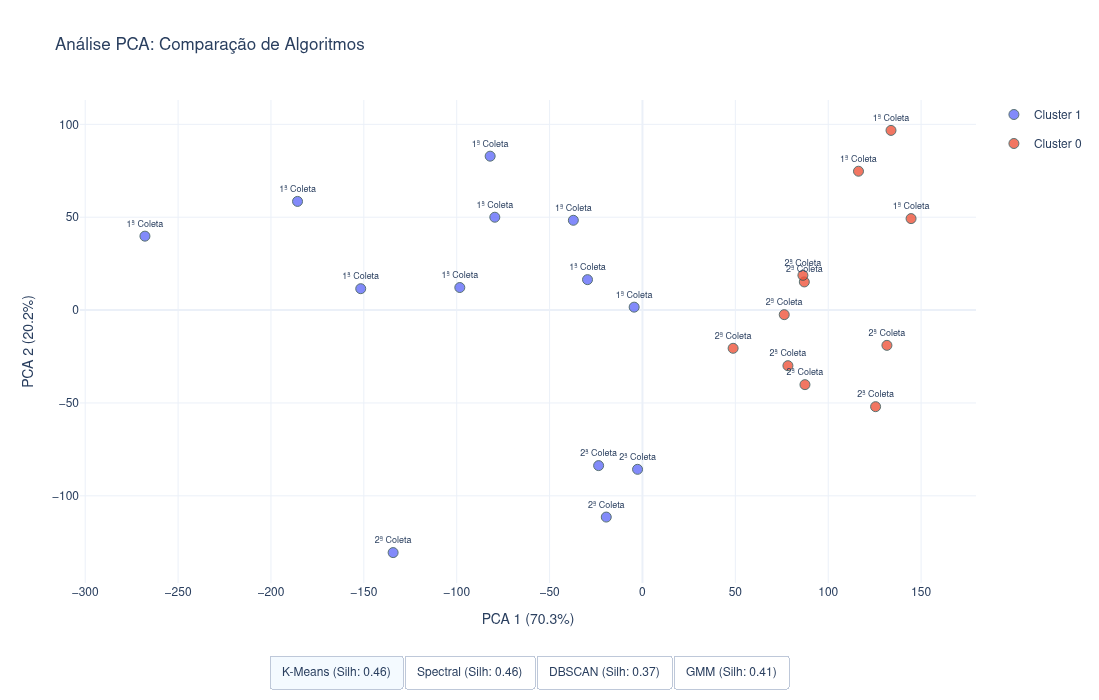

In [36]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

freq_max = 'Todas'
cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
all_freqs      = [col for col in df.columns if col not in cols_metadados]

if freq_max == 'Todas':
    freq_selected = all_freqs
    file_name = "Todas"
else:
    freq_selected = [
        col for col in all_freqs 
        if freq_min <= float(col) <= freq_max
    ]
    file_name = f"{freq_max}_{freq_min}"

filtered = df[freq_selected].values

redutor = PCA(n_components=2, random_state=42)
data    = redutor.fit_transform(filtered)

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)

spectral = SpectralClustering(
    n_clusters=n_clusters, 
    random_state=42, 
    assign_labels='kmeans',
    affinity='nearest_neighbors'
).fit(data)

dbscan = DBSCAN(eps=100, min_samples=5).fit(data) 

gmm = GaussianMixture(n_components=n_clusters, random_state=42).fit(data)
labels_gmm = gmm.predict(data)

sil_km = silhouette_score(data, kmeans.labels_)
sil_sp = silhouette_score(data, spectral.labels_)
sil_gm = silhouette_score(data, labels_gmm)

if len(set(dbscan.labels_)) > 1:
    sil_db = silhouette_score(data, dbscan.labels_)
    db_label = f"DBSCAN (Silh: {sil_db:.2f})"
else:
    db_label = "DBSCAN (Silh: N/A)"

ari_km_prod = adjusted_rand_score(df['IDX_produtor'], kmeans.labels_)
ari_sp_prod = adjusted_rand_score(df['IDX_produtor'], spectral.labels_)
ari_db_prod = adjusted_rand_score(df['IDX_produtor'], dbscan.labels_)
ari_gm_prod = adjusted_rand_score(df['IDX_produtor'], labels_gmm)

ari_km_rod = adjusted_rand_score(df['Rodada_coleta'], kmeans.labels_)
ari_sp_rod = adjusted_rand_score(df['Rodada_coleta'], spectral.labels_)
ari_db_rod = adjusted_rand_score(df['Rodada_coleta'], dbscan.labels_)
ari_gm_rod = adjusted_rand_score(df['Rodada_coleta'], labels_gmm)

ari_km_abelha = adjusted_rand_score(df['Abelha'], kmeans.labels_)
ari_sp_abelha = adjusted_rand_score(df['Abelha'], spectral.labels_)
ari_db_abelha = adjusted_rand_score(df['Abelha'], dbscan.labels_)
ari_gm_abelha = adjusted_rand_score(df['Abelha'], labels_gmm)

print("\n--- Validação Externa: Clusters vs Metadados (Adjusted Rand Index) ---")
print("O ARI varia de -1 a 1. Valores próximos a 1 indicam forte concordância.")
print("Valores próximos a 0 indicam que os clusters foram formados aleatoriamente em relação à variável.\n")

df_ari = pd.DataFrame({
    'Algoritmo': ['KMeans', 'Spectral', 'DBSCAN', 'GMM'],
    'ARI vs Produtor': [ari_km_prod, ari_sp_prod, ari_db_prod, ari_gm_prod],
    'ARI vs Rodada': [ari_km_rod, ari_sp_rod, ari_db_rod, ari_gm_rod],
    'ARI vs Abelha': [ari_km_abelha, ari_sp_abelha, ari_db_abelha, ari_gm_abelha]
})
print(df_ari.round(4).to_markdown(index=False))
print("\n" + "-"*65 + "\n")

df_2D = pd.DataFrame(data=data, columns=['PCA 1', 'PCA 2'])

df_2D['IDX_produtor']  = ('Produtor ' + df['IDX_produtor'].astype(str)).values
df_2D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Coleta').values
df_2D['Abelha']        = df['Abelha'].values

df_2D['KMeans']   = [f'Cluster {i}' for i in kmeans.labels_]
df_2D['Spectral'] = [f'Cluster {i}' for i in spectral.labels_]
df_2D['DBSCAN']   = [f'Cluster {i}' if i != -1 else 'Ruído' for i in dbscan.labels_]
df_2D['GMM']      = [f'Cluster {i}' for i in labels_gmm]

hover_config = {'PCA 1': False, 'PCA 2': False, 'IDX_produtor': True}

fig_kmeans = px.scatter(df_2D, x='PCA 1', y='PCA 2', color='KMeans', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_spectral = px.scatter(df_2D, x='PCA 1', y='PCA 2', color='Spectral', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_dbscan = px.scatter(df_2D, x='PCA 1', y='PCA 2', color='DBSCAN', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_gmm = px.scatter(df_2D, x='PCA 1', y='PCA 2', color='GMM', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)

fig = go.Figure()

for trace in fig_kmeans.data:
    fig.add_trace(trace)

for trace in fig_spectral.data:
    trace.visible = False
    fig.add_trace(trace)

for trace in fig_dbscan.data:
    trace.visible = False
    fig.add_trace(trace)

for trace in fig_gmm.data:
    trace.visible = False
    fig.add_trace(trace)

n_km = len(fig_kmeans.data)
n_sp = len(fig_spectral.data)
n_db = len(fig_dbscan.data)
n_gm = len(fig_gmm.data)

show_km = [True]  * n_km + [False] * n_sp + [False] * n_db + [False] * n_gm
show_sp = [False] * n_km + [True]  * n_sp + [False] * n_db + [False] * n_gm
show_db = [False] * n_km + [False] * n_sp + [True]  * n_db + [False] * n_gm
show_gm = [False] * n_km + [False] * n_sp + [False] * n_db + [True]  * n_gm

my_buttons = [
    dict(label=f"K-Means (Silh: {sil_km:.2f})", method="update", args=[{"visible": show_km}]),
    dict(label=f"Spectral (Silh: {sil_sp:.2f})", method="update", args=[{"visible": show_sp}]),
    dict(label=db_label, method="update", args=[{"visible": show_db}]),
    dict(label=f"GMM (Silh: {sil_gm:.2f})", method="update", args=[{"visible": show_gm}])
]

fig.update_layout(
    title=f'Análise PCA: Comparação de Algoritmos',
    template='plotly_white',
    width=800, 
    height=700,
    xaxis_title=f'PCA 1 ({redutor.explained_variance_ratio_[0]*100:.1f}%)',
    yaxis_title=f'PCA 2 ({redutor.explained_variance_ratio_[1]*100:.1f}%)',
    yaxis=dict(scaleanchor="x", scaleratio=1),
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            y=-0.15,
            xanchor="center",
            yanchor="top",
            showactive=True,
            buttons=my_buttons 
        )
    ]
)

fig.update_traces(
    textposition='top center',
    textfont_size=9, 
    marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
)

fig.show()


--- Validação Externa: Clusters vs Metadados (Adjusted Rand Index) ---
O ARI varia de -1 a 1. Valores próximos a 1 indicam forte concordância.
Valores próximos a 0 indicam que os clusters foram formados aleatoriamente em relação à variável.

| Algoritmo   |   ARI vs Produtor |   ARI vs Rodada |   ARI vs Abelha |
|:------------|------------------:|----------------:|----------------:|
| KMeans      |           -0.0484 |          0.5439 |          0.0227 |
| Spectral    |           -0.0484 |          0.5439 |          0.0227 |
| DBSCAN      |            0      |          0      |          0      |
| GMM         |           -0.0484 |          0.5439 |          0.0227 |

-----------------------------------------------------------------



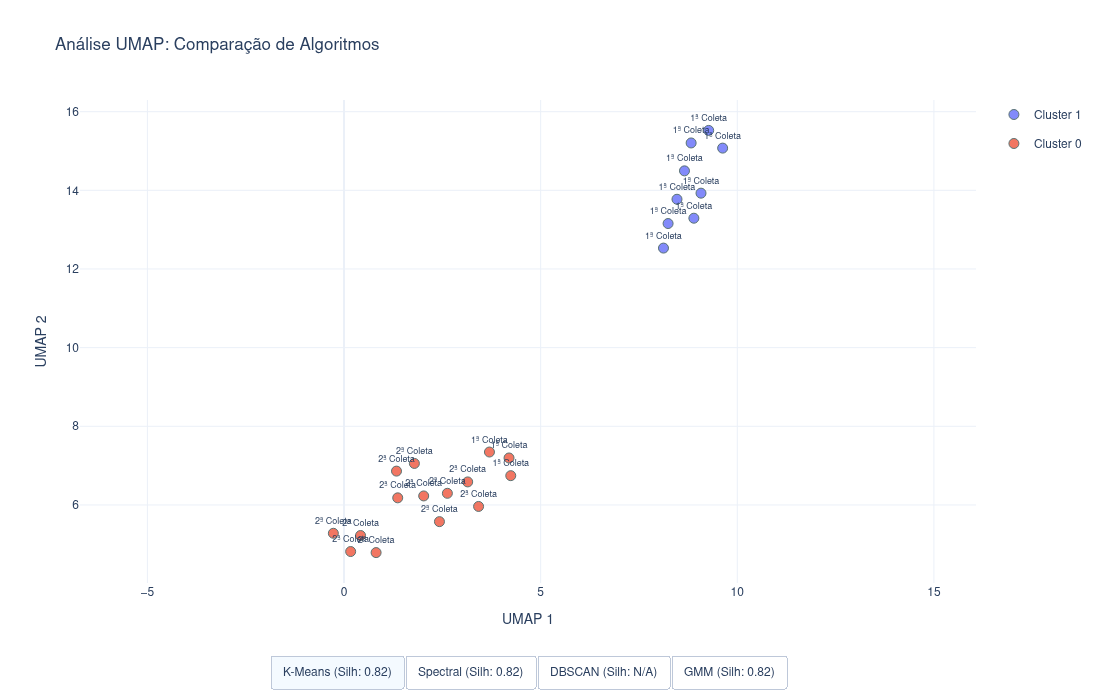

In [34]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from umap import UMAP
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

df = df.query("IDX_produtor != 7 & IDX_produtor != 8")

freq_max = 'Todas'
cols_metadados = ['Dia_coleta', 'Abelha', 'IDX_produtor', 'Rodada_coleta']
all_freqs      = [col for col in df.columns if col not in cols_metadados]

if freq_max == 'Todas':
    freq_selected = all_freqs
    file_name = "Todas"
else:
    freq_selected = [
        col for col in all_freqs 
        if freq_min <= float(col) <= freq_max
    ]
    file_name = f"{freq_max}_{freq_min}"

filtered = df[freq_selected].values

redutor = UMAP(n_components=2, n_neighbors=5, min_dist=0.3, random_state=42)
data    = redutor.fit_transform(filtered)

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)

spectral = SpectralClustering(
    n_clusters=n_clusters, 
    random_state=42, 
    assign_labels='kmeans',
    affinity='nearest_neighbors'
).fit(data)

dbscan = DBSCAN(eps=0.5, min_samples=5).fit(data) 

gmm = GaussianMixture(n_components=n_clusters, random_state=42).fit(data)
labels_gmm = gmm.predict(data)

sil_km = silhouette_score(data, kmeans.labels_)
sil_sp = silhouette_score(data, spectral.labels_)
sil_gm = silhouette_score(data, labels_gmm)

if len(set(dbscan.labels_)) > 1:
    sil_db = silhouette_score(data, dbscan.labels_)
    db_label = f"DBSCAN (Silh: {sil_db:.2f})"
else:
    db_label = "DBSCAN (Silh: N/A)"

ari_km_prod = adjusted_rand_score(df['IDX_produtor'], kmeans.labels_)
ari_sp_prod = adjusted_rand_score(df['IDX_produtor'], spectral.labels_)
ari_db_prod = adjusted_rand_score(df['IDX_produtor'], dbscan.labels_)
ari_gm_prod = adjusted_rand_score(df['IDX_produtor'], labels_gmm)

ari_km_rod = adjusted_rand_score(df['Rodada_coleta'], kmeans.labels_)
ari_sp_rod = adjusted_rand_score(df['Rodada_coleta'], spectral.labels_)
ari_db_rod = adjusted_rand_score(df['Rodada_coleta'], dbscan.labels_)
ari_gm_rod = adjusted_rand_score(df['Rodada_coleta'], labels_gmm)

ari_km_abelha = adjusted_rand_score(df['Abelha'], kmeans.labels_)
ari_sp_abelha = adjusted_rand_score(df['Abelha'], spectral.labels_)
ari_db_abelha = adjusted_rand_score(df['Abelha'], dbscan.labels_)
ari_gm_abelha = adjusted_rand_score(df['Abelha'], labels_gmm)

print("\n--- Validação Externa: Clusters vs Metadados (Adjusted Rand Index) ---")
print("O ARI varia de -1 a 1. Valores próximos a 1 indicam forte concordância.")
print("Valores próximos a 0 indicam que os clusters foram formados aleatoriamente em relação à variável.\n")

df_ari = pd.DataFrame({
    'Algoritmo': ['KMeans', 'Spectral', 'DBSCAN', 'GMM'],
    'ARI vs Produtor': [ari_km_prod, ari_sp_prod, ari_db_prod, ari_gm_prod],
    'ARI vs Rodada': [ari_km_rod, ari_sp_rod, ari_db_rod, ari_gm_rod],
    'ARI vs Abelha': [ari_km_abelha, ari_sp_abelha, ari_db_abelha, ari_gm_abelha]
})
print(df_ari.round(4).to_markdown(index=False))
print("\n" + "-"*65 + "\n")

df_2D = pd.DataFrame(data=data, columns=['UMAP 1', 'UMAP 2'])

df_2D['IDX_produtor']  = ('Produtor ' + df['IDX_produtor'].astype(str)).values
df_2D['Rodada_coleta'] = (df['Rodada_coleta'].astype(str) + 'ª Coleta').values
df_2D['Abelha']        = df['Abelha'].values

df_2D['KMeans']   = [f'Cluster {i}' for i in kmeans.labels_]
df_2D['Spectral'] = [f'Cluster {i}' for i in spectral.labels_]
df_2D['DBSCAN']   = [f'Cluster {i}' if i != -1 else 'Ruído' for i in dbscan.labels_]
df_2D['GMM']      = [f'Cluster {i}' for i in labels_gmm]

hover_config = {'UMAP 1': False, 'UMAP 2': False, 'IDX_produtor': True}

fig_kmeans = px.scatter(df_2D, x='UMAP 1', y='UMAP 2', color='KMeans', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_spectral = px.scatter(df_2D, x='UMAP 1', y='UMAP 2', color='Spectral', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_dbscan = px.scatter(df_2D, x='UMAP 1', y='UMAP 2', color='DBSCAN', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)
fig_gmm = px.scatter(df_2D, x='UMAP 1', y='UMAP 2', color='GMM', text='Rodada_coleta', hover_name='Abelha', hover_data=hover_config)

fig = go.Figure()

for trace in fig_kmeans.data:
    fig.add_trace(trace)

for trace in fig_spectral.data:
    trace.visible = False
    fig.add_trace(trace)

for trace in fig_dbscan.data:
    trace.visible = False
    fig.add_trace(trace)

for trace in fig_gmm.data:
    trace.visible = False
    fig.add_trace(trace)

n_km = len(fig_kmeans.data)
n_sp = len(fig_spectral.data)
n_db = len(fig_dbscan.data)
n_gm = len(fig_gmm.data)

show_km = [True]  * n_km + [False] * n_sp + [False] * n_db + [False] * n_gm
show_sp = [False] * n_km + [True]  * n_sp + [False] * n_db + [False] * n_gm
show_db = [False] * n_km + [False] * n_sp + [True]  * n_db + [False] * n_gm
show_gm = [False] * n_km + [False] * n_sp + [False] * n_db + [True]  * n_gm

my_buttons = [
    dict(label=f"K-Means (Silh: {sil_km:.2f})", method="update", args=[{"visible": show_km}]),
    dict(label=f"Spectral (Silh: {sil_sp:.2f})", method="update", args=[{"visible": show_sp}]),
    dict(label=db_label, method="update", args=[{"visible": show_db}]),
    dict(label=f"GMM (Silh: {sil_gm:.2f})", method="update", args=[{"visible": show_gm}])
]

fig.update_layout(
    title=f'Análise UMAP: Comparação de Algoritmos',
    template='plotly_white',
    width=800, 
    height=700,
    xaxis_title='UMAP 1',
    yaxis_title='UMAP 2',
    yaxis=dict(scaleanchor="x", scaleratio=1),
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            y=-0.15,
            xanchor="center",
            yanchor="top",
            showactive=True,
            buttons=my_buttons 
        )
    ]
)

fig.update_traces(
    textposition='top center',
    textfont_size=9, 
    marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey'))
)

fig.show()

In [29]:
filtered

array([[100, 99.9955133333333, 99.9927366666667, ..., 97.6765233333334,
        98.9393566666667, 100.83396],
       [100, 99.99462, 99.9940166666667, ..., 97.5163066666667, 99.32453,
        100.516735],
       [100, 100.001873333333, 100.003493333333, ..., 97.92563,
        99.2906833333333, 101.011926666667],
       ...,
       [100, 100, 100.01, ..., 100.1, 100.06, 100.16],
       [100, 100, 100, ..., 98.69, 98.64, 98.7],
       [100, 100, 100, ..., 99.61, 98.8, 97.9]],
      shape=(32, 3351), dtype=object)

,Dia_coleta,Abelha,IDX_produtor,4000,3999,3998,3997,3996,3995,3994,...,658,657,656,655,654,653,652,651,650,Rodada_coleta
1,1,Jataí,1,100,99.995513,99.992737,99.9917,99.99185,99.992837,99.994127,...,99.322983,98.514537,98.14798,98.87685,98.15767,96.38628,97.676523,98.939357,100.83396,1
2,2,Jataí,2,100,99.99462,99.994017,99.988213,99.982753,99.98002,99.981893,...,99.101097,98.686977,99.0192,99.381357,98.198847,97.36968,97.516307,99.32453,100.516735,1
3,3,Jataí,3,100,100.001873,100.003493,100.003477,100.00228,100.00145,100.0017,...,98.023333,97.086957,96.893953,97.247947,97.3147,97.140197,97.92563,99.290683,101.011927,1
4,4,Jataí,4,100,100.001053,100.000393,99.999377,99.994727,99.994683,99.997733,...,100.155547,99.407333,99.56157,98.271427,96.879717,96.023513,97.0668,98.72557,100.74969,1
5,5,Jataí,5,100,100.002107,100.002913,100.003307,99.99521,99.997057,100.00043,...,100.36313,99.592973,99.704393,100.024977,96.684607,95.810703,96.893257,98.506587,100.467617,1
6,6,Jataí,6,100,99.995467,99.992313,99.990977,99.989517,99.98673,99.98344,...,99.59384,99.817563,99.892533,99.975283,100.153513,100.266587,100.24297,100.063923,100.063923,1
9,1,Jataí,1,100,100,100,100.01,100.01,100.01,100,...,99.32,99.42,99.34,99.26,99.24,99.19,99.08,99.05,99.12,2
10,2,Jataí,2,100,100,99.99,99.99,99.99,99.99,99.99,...,98.39,98.57,98.56,98.47,98.4,98.29,98.16,98.12,98.14,2
11,3,Jataí,3,100,100,100,100,100,100,99.99,...,98.73,98.76,98.69,98.65,98.69,98.63,98.46,98.39,98.48,2
12,4,Jataí,4,100,100.01,100.01,100.02,100.01,100.01,100,...,99.38,99.55,99.56,99.54,99.54,99.44,99.25,99.18,99.28,2
